# Transfer Learning from Pre-Trained Models  

Using the notebook from 02_transfer_learning.ipynb

In [1]:
import torch

device = "cpu"

if torch.cuda.is_available():
    device = "cuda"

elif torch.backends.mps.is_available():
    device = "mps"

print(f'Using device: {device}')

Using device: mps


## **Step 1** - Prepare Dataset



In [2]:
# we choose 224 because this is the input resolution of the VGG16 model
image_resolution = 224 

# how many colour channels?
# 3 for RGB, 1 for greyscale
colour_channels = 3

# make sure the path to your image folder is correct
folder_path = '/Users/whisky/Desktop/Coding AI/Final/Image_classifier/pop art'

from torchvision.transforms.v2 import Compose, ToImage, ToDtype, Grayscale, Resize, RandomCrop, Normalize

# this transformation function will help us pre-process images during the training (on-the-fly)
transformation = Compose([   
    # convert an image to tensor
    ToImage(),
    ToDtype(torch.float32, scale=True),
    
    # resize and crop
    Resize(image_resolution),
    RandomCrop(image_resolution),
    
    # normalise pixel values to be between -1 and 1 
    Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    
    # if you're training on greyscale images, convert them to greyscale
    # otherwise just do nothing
    Grayscale() if colour_channels == 1 else torch.nn.Identity()
    
])


from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import torch
import torchvision

from torch import nn

from IPython.display import display

from torchvision.transforms.functional import to_pil_image
from torchvision.utils import make_grid


# how many images are going to be put into the testing set, 
# e.g. 0.2 means 20% percent of images
test_size = 0.2 

# how many images will be used in one epoch, 
# this usually depend on your model / types of data / CPU or GPU's capability
batch_size = 16


# Instatiate train and test datasets
train_dataset = ImageFolder(folder_path, transform=transformation)
test_dataset = ImageFolder(folder_path, transform=transformation)

# Get length of dataset and indicies
num_train = len(train_dataset)
indices = list(range(num_train))

# Get train / test split for data points
train_indices, test_indices = train_test_split(indices, test_size=test_size, random_state=42)

# Override dataset classes to only be samples for each split
train_sub_dataset = torch.utils.data.Subset(train_dataset, train_indices)
test_sub_dataset = torch.utils.data.Subset(test_dataset, test_indices)

# Create training and tresing data loaders
train_loader = DataLoader(train_sub_dataset, batch_size=batch_size, num_workers=4, multiprocessing_context="forkserver" if device=='mps' else None, shuffle=True)
test_loader = DataLoader(test_sub_dataset, batch_size=batch_size, num_workers=4, multiprocessing_context="forkserver" if device=='mps' else None, shuffle=True)

# sort out the names for each classes (according to the folder names)
class_names = train_dataset.classes

print(f'{len(train_indices)} training images loaded')
print(f'{len(test_indices)} testing images loaded')
print(f'classes: {class_names}')

data, labels = next(iter(train_loader))

print(f'data shape: {data.shape}')
print(f'labels shape: {labels.shape}')

521 training images loaded
131 testing images loaded
classes: ['popart(face)', 'popart(noface)']
data shape: torch.Size([16, 3, 224, 224])
labels shape: torch.Size([16])


## **Step 2** - Load the pre-trained model  



In [3]:
model = torchvision.models.vgg11(weights='IMAGENET1K_V1')
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [4]:
# freeze all model parameters
for param in model.parameters():
    param.requires_grad = False

    # replace the last two fully connected layers with new ones.
model.classifier[3] = nn.Linear(model.classifier[3].in_features, 256)
model.classifier[6] = nn.Linear(256, 5)

model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

## **Step 3** - Train the model

Now we can used the training workflow to train the model



#### Define optimiser and loss function

In [5]:
# Cross entropy loss
loss_function = torch.nn.CrossEntropyLoss().to(device)

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters())

#### Define training/ testing loop  

In [6]:
# we can save the model regularly
save_every_n_epoch = 5

# total number of epochs we aim for
num_epochs = 16

# keep track of the losses, we can plot them in the end
train_losses = []
test_losses = []

print('Epoch 0')

for epoch in range(num_epochs): 

    #---- Training loop -----------------------------
    train_loss = 0.0
    model.train()
    
    for i, data in enumerate(train_loader, 0):
        # Load: The training data loader loads a batch of training data and their true class labels.
        inputs, true_labels = data
        inputs = inputs.to(device)
        true_labels = true_labels.to(device)
        
        # Pass: Forward pass the training data to our model, and get the predicted classes.
        pred_labels = model(inputs)
        
        # Loss: The loss function compares the predicted classes to the true classes, and calculates the error.
        loss = loss_function(pred_labels, true_labels)
        train_loss += loss.item()
        
        # Optimise: The optimizer slightly optimises our model based on the error.
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        if i % 50 == 0:
            print(f'  -> Step {i + 1:04}, train loss: {loss.item():.4f}')
    
    
    #---- Testing loop -----------------------------
    test_loss = 0.0
    model.eval()
    
    with torch.inference_mode():
        test_loss = 0.0
        for i, data in enumerate(test_loader, 0):
            # Load: The testing data loader loads a batch of testing data and their true class labels.
            inputs, true_labels = data
            inputs = inputs.to(device)
            true_labels = true_labels.to(device)
            
            # Pass: Forward pass the testing data to our model, and get the predicted classes.
            pred_labels = model(inputs)
            
            # Loss: The loss function compares the predicted classes to the true classes, and calculates the error.
            loss = loss_function(pred_labels, true_labels)
            test_loss += loss.item()
    
    
    #---- Report some numbers -----------------------------
    
    # Calculate the cumulative losses in this epoch
    train_loss = train_loss / len(train_loader)
    test_loss = test_loss / len(test_loader)
    
    # Added cumulative losses to lists for later display
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    print(f'Epoch {epoch + 1}, train loss: {train_loss:.3f}, test loss: {test_loss:.3f}')
    
    # save our model every n epoch
    if (epoch+1) % save_every_n_epoch==0:
        torch.save(model.state_dict(), f'model_epoch{epoch:04}.pt')
        
# save the model at the end of the training process
torch.save(model.state_dict(), f'model_final.pt')

print("training finished, model saved to 'model_final.pt'")

Epoch 0
  -> Step 0001, train loss: 1.5631
Epoch 1, train loss: 0.310, test loss: 0.127
  -> Step 0001, train loss: 0.0163
Epoch 2, train loss: 0.148, test loss: 0.375
  -> Step 0001, train loss: 0.0401
Epoch 3, train loss: 0.079, test loss: 0.092
  -> Step 0001, train loss: 0.0252
Epoch 4, train loss: 0.059, test loss: 0.095
  -> Step 0001, train loss: 0.0253
Epoch 5, train loss: 0.064, test loss: 0.218
  -> Step 0001, train loss: 0.0989
Epoch 6, train loss: 0.080, test loss: 0.115
  -> Step 0001, train loss: 0.0688
Epoch 7, train loss: 0.029, test loss: 0.099
  -> Step 0001, train loss: 0.0045
Epoch 8, train loss: 0.033, test loss: 0.118
  -> Step 0001, train loss: 0.0000
Epoch 9, train loss: 0.018, test loss: 0.120
  -> Step 0001, train loss: 0.0034
Epoch 10, train loss: 0.031, test loss: 0.172
  -> Step 0001, train loss: 0.3381
Epoch 11, train loss: 0.052, test loss: 0.129
  -> Step 0001, train loss: 0.0004
Epoch 12, train loss: 0.040, test loss: 0.095
  -> Step 0001, train loss: 0

#### Plot Training Process


In [7]:
import matplotlib.pyplot as plt
import numpy as np

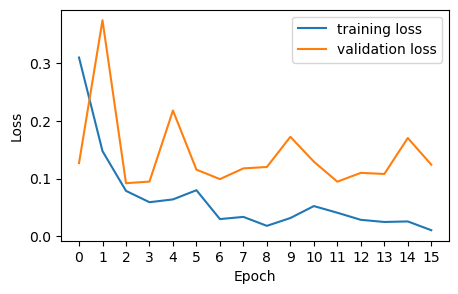

In [8]:
plt.figure(figsize=(5,3))
plt.plot(train_losses, label='training loss')
plt.plot(test_losses, label = 'validation loss')
plt.xticks(np.arange(len(train_losses)))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

## **Step 4** - Calculate accuracy  

Now we can run our model on the full testing set to calculate the accuracy of our model.  

Compare the result with the model that we trained from scratch in the first notebook. Does the accuracy improve?

In [9]:
num_samples = 0
num_correct = 0

with torch.inference_mode():
    for i, data in enumerate(test_loader, 0):
        # Load: The testing data loader loads a batch of testing data and their true class labels.
        inputs, true_labels = data
        inputs = inputs.to(device)
        true_labels = true_labels.to(device)

        # Pass: Forward pass the testing data to our model, and get the predicted classes.
        pred_labels = model(inputs)
        pred_labels = torch.argmax(pred_labels, dim=1)
        
        num_correct += pred_labels.size(0) - torch.count_nonzero(pred_labels - true_labels)
        num_samples += pred_labels.size(0) 
        
accuracy = num_correct / num_samples
print(f'correct samples: {num_correct}  \ntotal samples: {num_samples}  \nmodel accuracy: {accuracy:.3f}')

correct samples: 124  
total samples: 131  
model accuracy: 0.947
